In [3]:
#We are installing required libraries first
#adding few lines of code
!pip install datasets pandas matplotlib seaborn


In [4]:
# Load & Explore ATIS Dataset (Using HuggingFace Datasets)

import pandas as pd

def load_atis_split(split_dir):
    with open(f"{split_dir}/label", 'r', encoding='utf-8') as f:
        intents = f.read().splitlines()
        
    with open(f"{split_dir}/seq.in", 'r', encoding='utf-8') as f:
        utterances = f.read().splitlines()
        
    with open(f"{split_dir}/seq.out", 'r', encoding='utf-8') as f:
        slots = f.read().splitlines()
    
    # Build a DataFrame
    df = pd.DataFrame({
        'intent': intents,
        'utterance': utterances,
        'slots': slots
    })
    
    return df


In [5]:
train_df = load_atis_split("atis/train")
test_df = load_atis_split("atis/test")
valid_df = load_atis_split("atis/valid")

# Preview
print("Train Set Sample:\n", train_df.head())
print("\nNumber of unique intents:", train_df['intent'].nunique())


Train Set Sample:
          intent                                          utterance  \
0   atis_flight  i want to fly from baltimore to dallas round trip   
1  atis_airfare  round trip fares from baltimore to philadelphi...   
2   atis_flight  show me the flights arriving on baltimore on j...   
3   atis_flight  what are the flights which depart from san fra...   
4  atis_airline  which airlines fly from boston to washington d...   

                                               slots  
0  O O O O O B-fromloc.city_name O B-toloc.city_n...  
1  B-round_trip I-round_trip O O B-fromloc.city_n...  
2  O O O O O O B-toloc.city_name O B-arrive_date....  
3  O O O O O O O B-fromloc.city_name I-fromloc.ci...  
4  O O O O B-fromloc.city_name O B-toloc.city_nam...  

Number of unique intents: 21


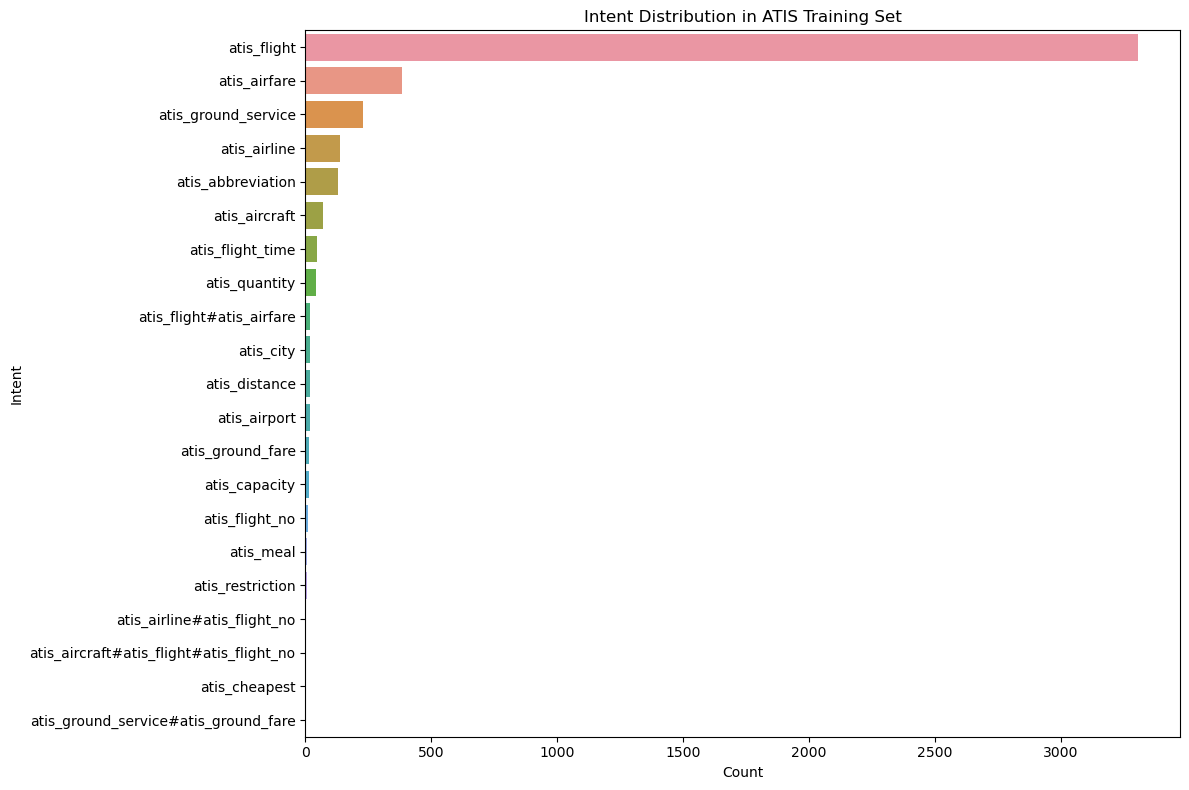

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.countplot(y=train_df['intent'], order=train_df['intent'].value_counts().index)
plt.title("Intent Distribution in ATIS Training Set")
plt.xlabel("Count")
plt.ylabel("Intent")
plt.tight_layout()
plt.savefig("intent_distribution.png")
plt.show()


# Text Preprocessing

In [7]:

!pip install tensorflow scikit-learn

# Preprocessing, Tokenization & Encode Intent Labels

from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# -------------------
# Step 1: Clean the text
# -------------------
train_df['utterance'] = train_df['utterance'].str.lower().str.strip()
test_df['utterance'] = test_df['utterance'].str.lower().str.strip()
valid_df['utterance'] = valid_df['utterance'].str.lower().str.strip()

# -------------------
# Step 2: Fit Tokenizer on TRAIN utterances only
# -------------------
tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts(train_df['utterance'])

# -------------------
# Step 3: Fit LabelEncoder on TRAIN intents only
# -------------------
label_encoder = LabelEncoder()
label_encoder.fit(train_df['intent'])

# -------------------
# Step 4: Filter unseen intents from test and valid sets
# -------------------
test_df = test_df[test_df['intent'].isin(label_encoder.classes_)]
valid_df = valid_df[valid_df['intent'].isin(label_encoder.classes_)]

# -------------------
# Step 5: Convert text to sequences and pad
# (Do this AFTER filtering, so lengths match)
# -------------------
max_len = max(train_df['utterance'].apply(lambda x: len(x.split())))  # dynamic max_len

X_train = tokenizer.texts_to_sequences(train_df['utterance'])
X_train = pad_sequences(X_train, maxlen=max_len, padding='post')

X_test = tokenizer.texts_to_sequences(test_df['utterance'])
X_test = pad_sequences(X_test, maxlen=max_len, padding='post')

X_valid = tokenizer.texts_to_sequences(valid_df['utterance'])
X_valid = pad_sequences(X_valid, maxlen=max_len, padding='post')

# -------------------
# Step 6: Encode the intent labels
# -------------------
y_train = label_encoder.transform(train_df['intent'])
y_test = label_encoder.transform(test_df['intent'])
y_valid = label_encoder.transform(valid_df['intent'])

# -------------------
# Step 7: Check shapes
# -------------------
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print("X_valid shape:", X_valid.shape)
print("y_valid shape:", y_valid.shape)



X_train shape: (4478, 46)
y_train shape: (4478,)
X_test shape: (888, 46)
y_test shape: (888,)
X_valid shape: (499, 46)
y_valid shape: (499,)


# Intent Recognition Model

In [8]:
# Define a Simple Deep Neural Network (DNN) Classifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense, Dropout

# Define key sizes
vocab_size = len(tokenizer.word_index) + 1  # Add 1 for padding token
embedding_dim = 64
input_length = X_train.shape[1]
num_classes = len(label_encoder.classes_)

# Build the model
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=input_length),
    GlobalAveragePooling1D(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Force the model to build with the correct input shape
model.build(input_shape=(None, input_length))

# Show model summary
model.summary()



C:\Users\adnan\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 46, 64)         │        55,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 21)             │         1,365 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,141 (238.83 KB)

 Trainable params: 61,141 (238.83 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Train the Model

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_valid, y_valid),
    verbose=1
)


Epoch 1/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.6976 - loss: 1.8544 - val_accuracy: 0.7154 - val_loss: 1.2601
Epoch 2/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7472 - loss: 1.1575 - val_accuracy: 0.7154 - val_loss: 1.1740
Epoch 3/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7441 - loss: 1.0742 - val_accuracy: 0.7154 - val_loss: 1.0304
Epoch 4/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7535 - loss: 0.9244 - val_accuracy: 0.7475 - val_loss: 0.9145
Epoch 5/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7856 - loss: 0.8003 - val_accuracy: 0.7575 - val_loss: 0.8463
Epoch 6/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8008 - loss: 0.7517 - val_accuracy: 0.7856 - val_loss: 0.7805
Epoch 7/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8251 - loss: 0.6940 - val_accuracy: 0.8277 - val_loss: 0.7145
Epoch 8/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8567 - loss: 0.5849 - val_accuracy: 0.

In [10]:
# Evaluate the Model
# Evaluate on test set
loss, acc = model.evaluate(X_test, y_test)
print(f" Test Accuracy: {acc:.4f}")


28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8676 - loss: 0.5055
 Test Accuracy: 0.8390


In [11]:
# Save Model and Tools

import pickle

# ✅ Save model in the new native Keras format
model.save("intent_model.keras")

# Save tokenizer
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

# Save label encoder
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)


# Plot Training Curves (Accuracy & Loss)

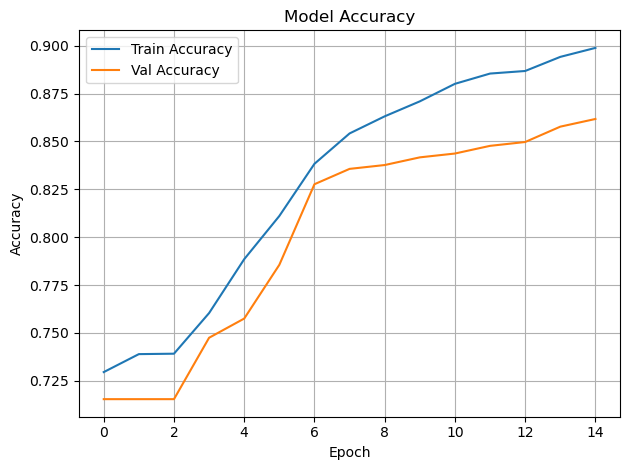

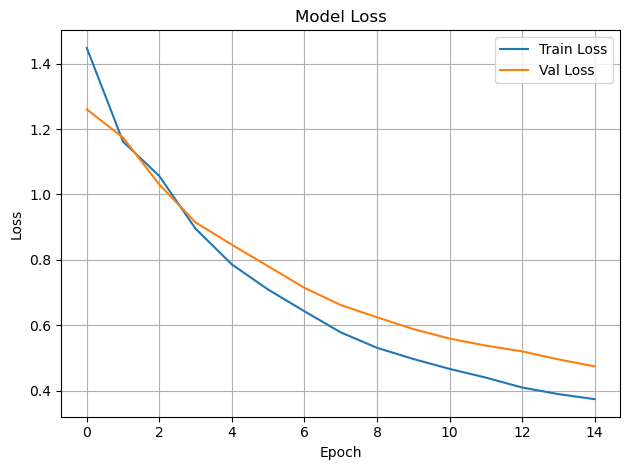

In [12]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("accuracy_curve.png")
plt.show()

# Loss plot
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("loss_curve.png")
plt.show()


# Generate Confusion Matrix and Classification Report

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
📋 Classification Report:
                          precision    recall  f1-score   support

       atis_abbreviation       0.40      1.00      0.57        33
           atis_aircraft       0.67      0.22      0.33         9
            atis_airfare       0.75      0.94      0.83        48
            atis_airline       0.39      0.18      0.25        38
            atis_airport       0.00      0.00      0.00        18
           atis_capacity       0.00      0.00      0.00        21
               atis_city       0.00      0.00      0.00         6
           atis_distance       0.00      0.00      0.00        10
             atis_flight       0.93      0.99      0.96       632
atis_flight#atis_airfare       0.00      0.00      0.00        12
          atis_flight_no       0.00      0.00      0.00         8
        atis_flight_time       0.00      0.00      0.00         1
        atis_ground_fare       0.00      0.00      0.00         7
     atis_

C:\Users\adnan\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\adnan\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\adnan\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


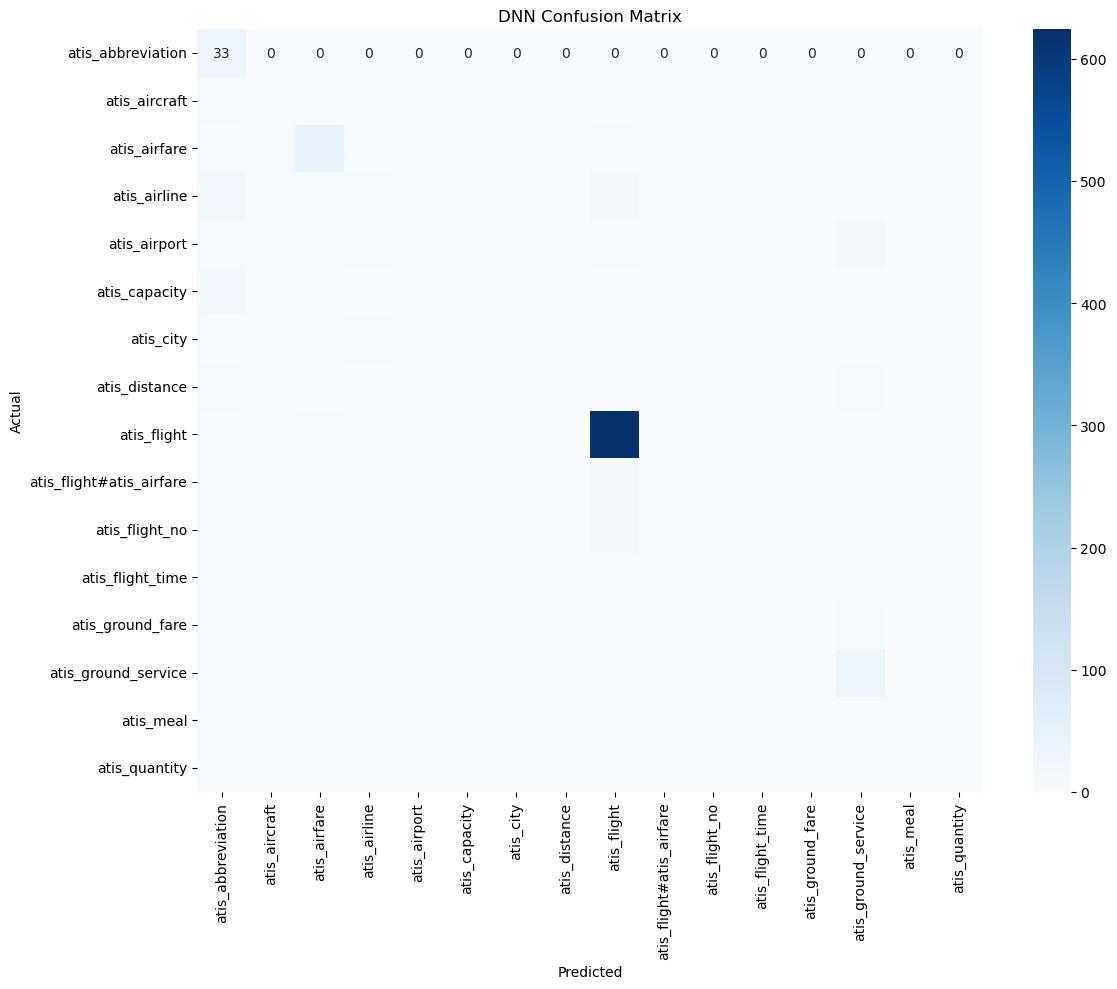

In [13]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Predict probabilities and then class indices
y_pred_probs = model.predict(X_test)
y_pred_classes = y_pred_probs.argmax(axis=1)

# Get only the classes present in y_test
unique_labels = sorted(set(y_test))
target_names = label_encoder.inverse_transform(unique_labels)

# ✅ Print classification report
print("📋 Classification Report:")
print(classification_report(y_test, y_pred_classes, labels=unique_labels, target_names=target_names))

# ✅ Plot confusion matrix
cm = confusion_matrix(y_test, y_pred_classes, labels=unique_labels)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=target_names,
            yticklabels=target_names,
            cmap='Blues')

plt.title("DNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()


# Real-Time Intent Prediction Function

In [14]:
# Function to Load Model, Tokenizer, and LabelEncoder

import pickle
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Load the trained model
model = load_model("intent_model.keras")

# Load tokenizer
with open("tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)

# Load label encoder
with open("label_encoder.pkl", "rb") as f:
    label_encoder = pickle.load(f)

# Get max_len used during training
max_len = model.input_shape[1]


In [15]:
# Real-Time Prediction Function

def predict_intent(user_input):
    # Step 1: Preprocess input
    user_input = user_input.lower().strip()
    seq = tokenizer.texts_to_sequences([user_input])
    padded = pad_sequences(seq, maxlen=max_len, padding='post')

    # Step 2: Predict intent
    pred_probs = model.predict(padded)
    pred_class = pred_probs.argmax(axis=1)[0]
    intent = label_encoder.inverse_transform([pred_class])[0]

    # Step 3: Return intent
    return intent


In [28]:
# Testing It
test_queries = [
    "book a flight from new york to seattle",
    "what's the cheapest fare to miami?",
    "which airlines fly to dallas?",
    "show me flights tomorrow evening"
]

for query in test_queries:
    intent = predict_intent(query)
    print(f"User: {query}\n→ Predicted intent: {intent}\n")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
User: book a flight from new york to seattle
→ Predicted intent: atis_flight

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
User: what's the cheapest fare to miami?
→ Predicted intent: atis_airfare

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
User: which airlines fly to dallas?
→ Predicted intent: atis_airline

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
User: show me flights tomorrow evening
→ Predicted intent: atis_flight



# LSTM Model Training and Evaluation

In [ ]:
# Build the LSTM Model

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

vocab_size = len(tokenizer.word_index) + 1
embedding_dim = 64
input_length = X_train.shape[1]
num_classes = len(label_encoder.classes_)

lstm_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=input_length),
    LSTM(128, return_sequences=False),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

lstm_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 👇 Force model to build
lstm_model.build(input_shape=(None, input_length))
lstm_model.summary()


C:\Users\adnan\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 46, 64)         │        55,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 21)             │         1,365 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 164,053 (640.83 KB)

 Trainable params: 164,053 (640.83 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# train the LSTM model

In [17]:
history_lstm = lstm_model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_valid, y_valid),
    verbose=1
)


Epoch 1/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 13s 47ms/step - accuracy: 0.7132 - loss: 1.6347 - val_accuracy: 0.7154 - val_loss: 1.2415
Epoch 2/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.7421 - loss: 1.1934 - val_accuracy: 0.7154 - val_loss: 1.2267
Epoch 3/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.7291 - loss: 1.2211 - val_accuracy: 0.7154 - val_loss: 1.2492
Epoch 4/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - accuracy: 0.7261 - loss: 1.2190 - val_accuracy: 0.7154 - val_loss: 1.2273
Epoch 5/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - accuracy: 0.7478 - loss: 1.1252 - val_accuracy: 0.7154 - val_loss: 1.2261
Epoch 6/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.7395 - loss: 1.1712 - val_accuracy: 0.7154 - val_loss: 1.2024
Epoch 7/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 0.7370 - loss: 1.1566 - val_accuracy: 0.7154 - val_loss: 1.2299
Epoch 8/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.7433 - loss: 1.1539 - val_acc

In [ ]:
# Evaluate Test Accuracy

In [18]:
loss, acc = lstm_model.evaluate(X_test, y_test)
print(f" LSTM Test Accuracy: {acc:.4f}")


28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7699 - loss: 1.1760
 LSTM Test Accuracy: 0.7117


In [ ]:
#It’s lower than the DNN model’s 83.67%, so:

#Either it's underfitting (not learning enough),

#Or it's overfitting to training data but failing to generalize.



In [ ]:
#Plot LSTM vs DNN Accuracy & Loss

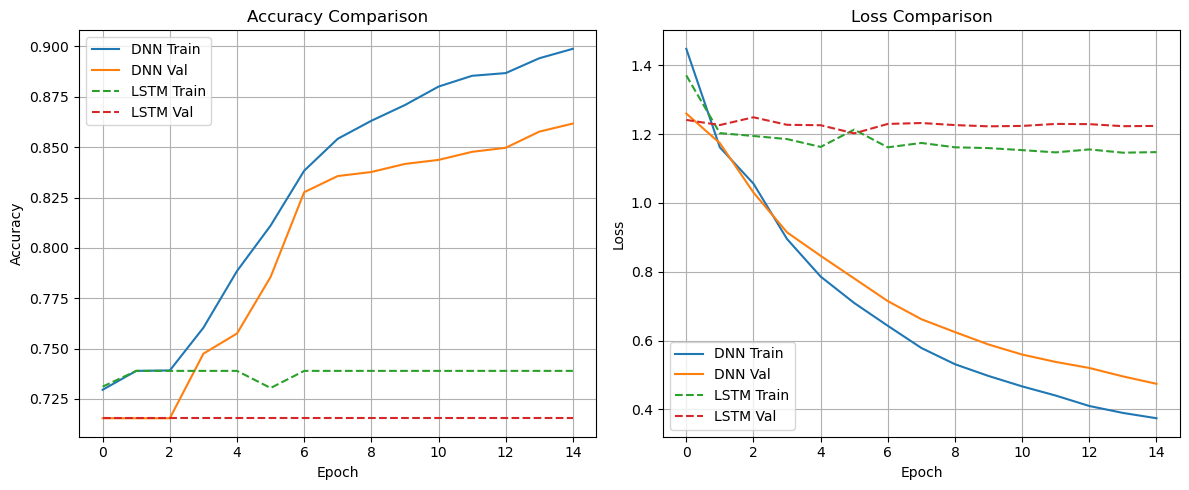

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# 📊 Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='DNN Train')
plt.plot(history.history['val_accuracy'], label='DNN Val')
plt.plot(history_lstm.history['accuracy'], label='LSTM Train', linestyle='--')
plt.plot(history_lstm.history['val_accuracy'], label='LSTM Val', linestyle='--')
plt.title('Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='DNN Train')
plt.plot(history.history['val_loss'], label='DNN Val')
plt.plot(history_lstm.history['loss'], label='LSTM Train', linestyle='--')
plt.plot(history_lstm.history['val_loss'], label='LSTM Val', linestyle='--')
plt.title('Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("lstm_vs_dnn_performance.png")
plt.show()


In [ ]:
# Generate Confusion Matrix for the LSTM Model

In [20]:
# Predict Classes on Test Set

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get predicted class probabilities
y_pred_probs_lstm = lstm_model.predict(X_test)

# Convert probabilities to class indices
y_pred_lstm = y_pred_probs_lstm.argmax(axis=1)


28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step


In [21]:
# Filter Class Labels to Avoid Label Mismatch

# Get actual unique class indices in y_test
unique_labels_lstm = sorted(set(y_test))

# Convert those to intent names
target_names_lstm = label_encoder.inverse_transform(unique_labels_lstm)


In [21]:
# Print Classification Report

print("📋 Classification Report (LSTM):")
print(classification_report(
    y_test,
    y_pred_lstm,
    labels=unique_labels_lstm,
    target_names=target_names_lstm
))


📋 Classification Report (LSTM):
                          precision    recall  f1-score   support

       atis_abbreviation       0.00      0.00      0.00        33
           atis_aircraft       0.00      0.00      0.00         9
            atis_airfare       0.00      0.00      0.00        48
            atis_airline       0.00      0.00      0.00        38
            atis_airport       0.00      0.00      0.00        18
           atis_capacity       0.00      0.00      0.00        21
               atis_city       0.00      0.00      0.00         6
           atis_distance       0.00      0.00      0.00        10
             atis_flight       0.91      0.97      0.93       632
atis_flight#atis_airfare       0.00      0.00      0.00        12
          atis_flight_no       0.00      0.00      0.00         8
        atis_flight_time       0.00      0.00      0.00         1
        atis_ground_fare       0.00      0.00      0.00         7
     atis_ground_service       0.15      0.

C:\Users\adnan\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\adnan\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\adnan\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step


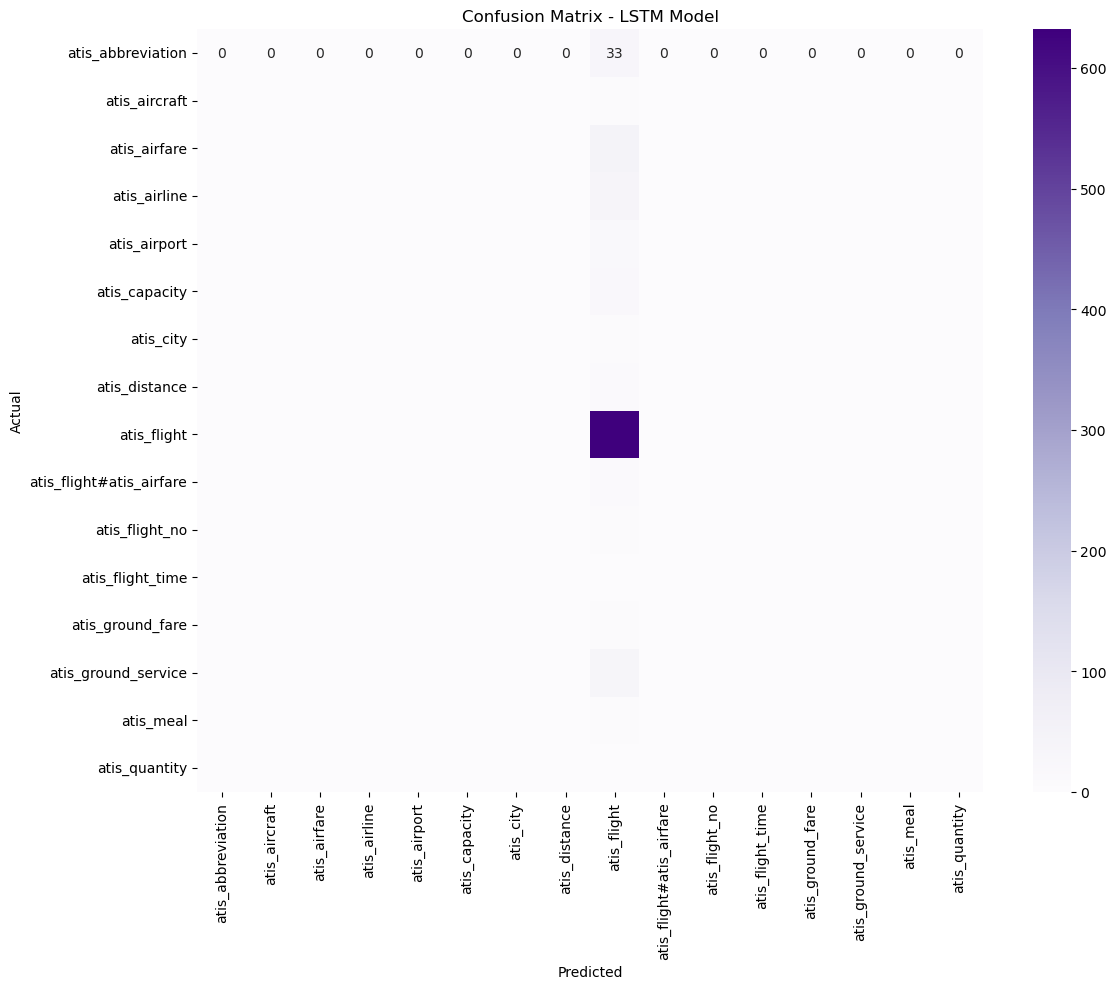

In [22]:
# Plot the Confusion Matrix

# ✅ LSTM Predictions
y_pred_probs_lstm = lstm_model.predict(X_test)
y_pred_lstm = y_pred_probs_lstm.argmax(axis=1)

# ✅ Get unique labels and target names
unique_labels_lstm = sorted(set(y_test))
target_names_lstm = label_encoder.inverse_transform(unique_labels_lstm)

# ✅ Confusion Matrix
cm_lstm = confusion_matrix(y_test, y_pred_lstm, labels=unique_labels_lstm)

plt.figure(figsize=(12, 10))
sns.heatmap(cm_lstm, annot=True, fmt='d',
            xticklabels=target_names_lstm,
            yticklabels=target_names_lstm,
            cmap='Purples')

plt.title("Confusion Matrix - LSTM Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("confusion_matrix_lstm.png")
plt.show()


# Sentiment Analysis

In [ ]:
# We’ll use VADER (Valence Aware Dictionary and sEntiment Reasoner)
# Pretrained

# Works great for chat-style, short text

# Gives you positive, neutral, or negative sentiment scores

In [23]:
# Install VADER (if not installed)

!pip install vaderSentiment

In [24]:
# Import and Create Sentiment Analyzer

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Create analyzer instance
sentiment_analyzer = SentimentIntensityAnalyzer()


In [25]:
# Define Sentiment Function

def get_sentiment(user_input):
    scores = sentiment_analyzer.polarity_scores(user_input)
    compound = scores['compound']

    if compound >= 0.05:
        return 'positive'
    elif compound <= -0.05:
        return 'negative'
    else:
        return 'neutral'


In [ ]:
# Combine Intent + Sentiment Prediction
# Assuming you’re using your DNN model now:

In [26]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
import pickle
from tensorflow.keras.models import load_model

# Load saved components
model = load_model("intent_model.keras")

with open("tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)

with open("label_encoder.pkl", "rb") as f:
    label_encoder = pickle.load(f)

max_len = model.input_shape[1]

# Final function to predict both
def predict_intent_and_sentiment(user_input):
    # Preprocess input
    clean = user_input.lower().strip()
    seq = tokenizer.texts_to_sequences([clean])
    padded = pad_sequences(seq, maxlen=max_len, padding='post')

    # Intent prediction
    pred_probs = model.predict(padded)
    pred_class = pred_probs.argmax(axis=1)[0]
    intent = label_encoder.inverse_transform([pred_class])[0]

    # Sentiment
    sentiment = get_sentiment(user_input)

    return intent, sentiment


C:\Users\adnan\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 7 variables whereas the saved optimizer has 12 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [27]:
# test it

examples = [
    "I’m really happy to fly business class to New York!",
    "Just book the cheapest ticket. I’m frustrated.",
    "Can I have flight options from Dallas tomorrow?"
]

for q in examples:
    intent, sentiment = predict_intent_and_sentiment(q)
    print(f"User: {q}")
    print(f"→ Intent: {intent} | Sentiment: {sentiment}\n")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 960ms/step
User: I’m really happy to fly business class to New York!
→ Intent: atis_flight | Sentiment: positive

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step
User: Just book the cheapest ticket. I’m frustrated.
→ Intent: atis_airfare | Sentiment: negative

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step
User: Can I have flight options from Dallas tomorrow?
→ Intent: atis_flight | Sentiment: neutral



# Chatbot

In [ ]:
!pip install streamlit

In [ ]:
!streamlit run chatbot_app.py



In [ ]:
import numpy as np

print("DNN Confusion Matrix")
print(confusion_matrix(y_test, y_pred_dnn))

print("LSTM Confusion Matrix")
print(confusion_matrix(y_test, y_pred_lstm))

# Or check if they're actually identical
print("Matrices Equal:", np.array_equal(
    confusion_matrix(y_test, y_pred_dnn),
    confusion_matrix(y_test, y_pred_lstm)
))
